In [5]:
import torch
print("CUDA available ",torch.cuda.is_available())
print("GPU NAME ",torch.cuda.get_device_name(0 if torch.cuda.is_available() else -1))

CUDA available  True
GPU NAME  NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
import torch.nn as nn
import torch.optim as optim


In [10]:
# device=torch.device("Cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)


# ✅ Auto-detect GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [11]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

In [12]:
# ✅ Move model to GPU
model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


In [15]:
inputs = torch.randn(64, 10).to(device)   # ✅ Push data to GPU
targets = torch.randn(64, 1).to(device)   # ✅ Push labels to GPU

In [16]:
# Training step
model.train()
for epoch in range(10):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.2194
Epoch 2, Loss: 1.2160
Epoch 3, Loss: 1.2126
Epoch 4, Loss: 1.2092
Epoch 5, Loss: 1.2059
Epoch 6, Loss: 1.2026
Epoch 7, Loss: 1.1994
Epoch 8, Loss: 1.1961
Epoch 9, Loss: 1.1929
Epoch 10, Loss: 1.1897


## LeNet

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D,AveragePooling2D
from keras.models import Sequential
from keras.datasets import mnist

: 

In [ ]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [ ]:
# LeNet Achitecture

model = Sequential()
model.add(Conv2D(6,kernel_size=(5,5),padding='valid',activation='tanh',input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(16,kernel_size=(5,5),padding='valid',activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(120,activation='tanh'))
model.add(Dense(84,activation='tanh'))
model.add(Dense(10,activation='softmax'))

d:\Programming\Deep_Learning_Concept\.deeplr\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(X_train.reshape(-1,28,28,1), y_train, epochs=10, batch_size=64, validation_data=(X_test.reshape(-1,28,28,1), y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8886 - loss: 0.3879 - val_accuracy: 0.9766 - val_loss: 0.0738
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9767 - loss: 0.0733 - val_accuracy: 0.9819 - val_loss: 0.0569
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9848 - loss: 0.0504 - val_accuracy: 0.9868 - val_loss: 0.0447
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9878 - loss: 0.0381 - val_accuracy: 0.9840 - val_loss: 0.0503
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9845 - val_loss: 0.0483
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9908 - loss: 0.0284 - val_accuracy: 0.9864 - val_loss: 0.0426
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9931 - loss: 0.0219 - val_accuracy: 0.9874 - val_loss: 0.0403
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.

In [ ]:
model.history.history

{'accuracy': [0.9451500177383423,
  0.9782999753952026,
  0.9849333167076111,
  0.987333357334137,
  0.9890333414077759,
  0.9907166957855225,
  0.9923333525657654,
  0.9934166669845581,
  0.9941333532333374,
  0.995283305644989],
 'loss': [0.1869739145040512,
  0.06916467100381851,
  0.049057502299547195,
  0.03907402604818344,
  0.03420592099428177,
  0.028935888782143593,
  0.02390049211680889,
  0.02043633908033371,
  0.01851770095527172,
  0.01536041684448719],
 'val_accuracy': [0.9765999913215637,
  0.9818999767303467,
  0.9868000149726868,
  0.984000027179718,
  0.984499990940094,
  0.9864000082015991,
  0.9873999953269958,
  0.9894999861717224,
  0.9869999885559082,
  0.989799976348877],
 'val_loss': [0.07381310313940048,
  0.05685104802250862,
  0.04467570781707764,
  0.05025807395577431,
  0.04831414669752121,
  0.04255109652876854,
  0.04025869071483612,
  0.03472082316875458,
  0.042262669652700424,
  0.03743570297956467]}

In [ ]:
# %pip install matplotlib
# %pip install scikit-learn
# %pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

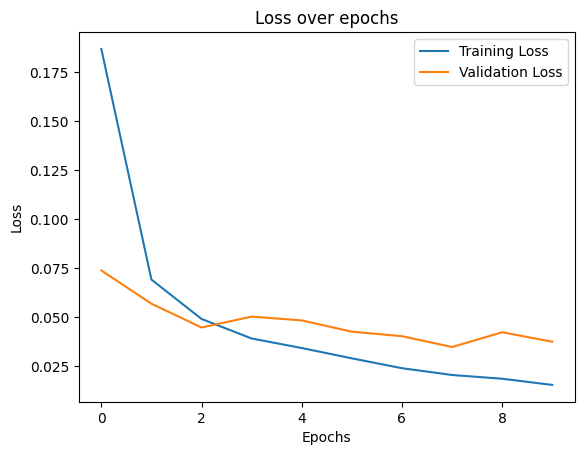

In [ ]:
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
